In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [5]:
import pandas as pd
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

<font size="5" color="black">ch05. 로지스틱회귀 분류(당뇨병_발병_예측)</font>
# 로지스틱 회귀 분석 (이진분류)

## 1. 데이터 생성 및 전처리

### CSV - 데이터프레임 - Numpy 배열

In [6]:
# 1. csv 파일 불러오기 (데이터프레임 : 결측치 확인 및 처리, 균형 확인 용이)
# 2. numpy 배열 변환
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)

In [15]:
# 임신 횟수
# 혈당
# 혈압
# 피부 두께
# 인슐린
# BMI
# 당뇨 내력 지수
# 나이
df.shape

(768, 9)

In [8]:
# 데이터프레임 구조 및 상태 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
# 열 별 결측치 확인
df.isna().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [10]:
# 타겟 변수의 균형(클래스별 개수 및 비율 확인) 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [11]:
# 데이터프레임을 numpy 배열로 변환
np.array(df)
df.values
dataset = df.to_numpy()

### CSV - Numpy 배열

In [125]:
# 1. csv 파일 불러오기 (넘파이 배열 : 결측치가 없음이 확인된 자료)
dataset = np.loadtxt('data/pima-indians-diabetes.csv', 
                     encoding='utf-8', # 기본값 : cp949, 인코딩 형식
                     delimiter=',', # 기본값 : None, 데이터 분할 기준
                     comments='#' # 기본값 : '#', 주석 처리 기준
                    )
dataset.shape

(768, 9)

### 데이터 분할
- 주의할 점 : 데이터셋 슬라이싱 전 데이터 편향(정렬 여부) 확인 필요

In [126]:
# 학습 데이터셋 (80%)
X_train = dataset[:620,:-1]
y_train = dataset[:620,-1:]

# 평가 데이터셋 (20%)
X_test = dataset[620:,:-1]
y_test = dataset[620:,-1:]

## 2. 모델 구성

In [127]:
model = Sequential()
# model.add(Dense(64, input_dim=8, activation='relu'))
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # sigmoid : 로지스틱 회귀분석(이진분류) 출력층 활성화 함수
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_29 (Dense)            (None, 32)                288       
                                                                 
 dense_30 (Dense)            (None, 64)                2112      
                                                                 
 dense_31 (Dense)            (None, 32)                2080      
                                                                 
 dense_32 (Dense)            (None, 16)                528       
                                                                 
 dense_33 (Dense)            (None, 1)                 17        
                                                                 
Total params: 5,025
Trainable params: 5,025
Non-trainable params: 0
_________________________________________________________________


```
[독립변수 8개]
      │
    (1층) ─> 8개 변수를 조합해 '64개의 새로운 특성' 생성
      │
    (2층) ─> 64개 특성을 조합해 '32개의 더 정교한 특성' 생성
      │
    (3층) ─> 32개 특성을 조합해 '16개의 핵심 특성' 생성
      │
   (출력층) ─> 16개 특성을 종합해 '1개의 최종 예측값(0~1 사이 확률)' 계산
      │
      ▼
 [Cost 계산] ─> 실제 정답(종속변수)과 예측값을 비교해 오차(Cost) 측정
      │
      ▼
   [역전파]  ─> 구한 Cost를 바탕으로 출력층 ➔ 3층 ➔ 2층 ➔ 1층의
             모든 W와 b를 동시에 조금씩 오차가 줄어드는 방향으로 수정
```

## 3. 학습과정 설정

In [128]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
# binary_crossentropy일 경우, metrics=['accuracy']는 자동으로 binary_accuracy로 작동함
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 4. 학습

In [129]:
%%time
hist = model.fit(X_train, y_train,
                epochs=200,
                batch_size=155,
                validation_split=0.1,
                verbose=0)

CPU times: total: 12.9 s
Wall time: 10.2 s


## 5. 모델 평가하기
- 학습과정 시각화
- 평가(시험 데이터셋)
- 교차표(혼동 매트릭스, 성능 평가 지표) 그리기

In [32]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

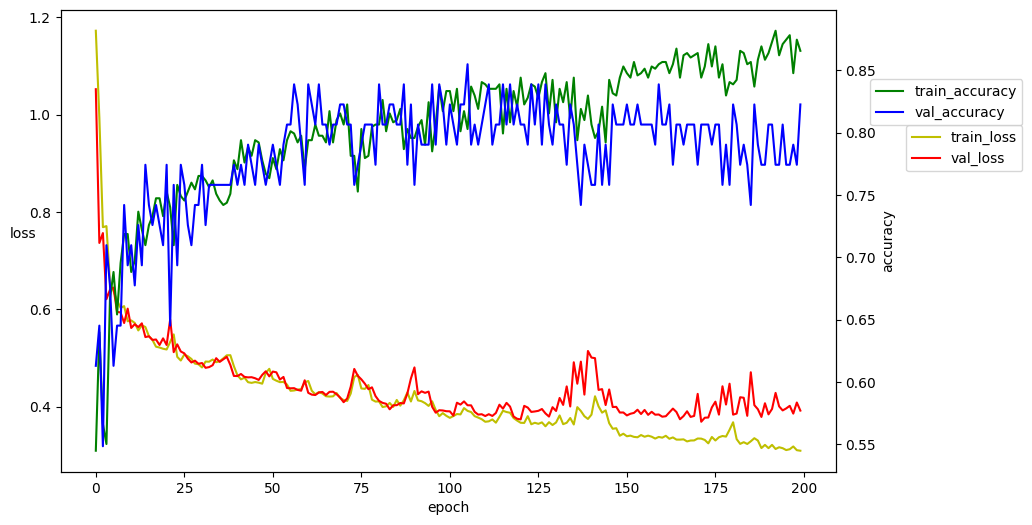

In [130]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.7), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.8), ncol=1)
plt.show()

In [131]:
# 모델 정확도 확인
loss, accuracy = model.evaluate(X_test, y_test)
print(f'정확도 : {accuracy*100:.2f}%')

5/5 [==============================] - 0s 1ms/step - loss: 0.6347 - accuracy: 0.7230
정확도 : 72.30%


### 교차표
- 혼동 매트릭스 & 성능 평가 지표

| | 예측: 0 (Negative) | 예측: 1 (Positive) |
| :--- | :--- | :--- |
| **실제: 0 (Negative)** | **TN** (True Negative) | **FP** (False Positive) |
| **실제: 1 (Positive)** | **FN** (False Negative) | **TP** (True Positive) |

- 정확도 (Accuracy) : 전체 중 맞춘 비율<p>$\frac{TN + TP}{TN + FP + FN + TP}$ </p>
    
- 정밀도 (Precision) : 모델이 1로 예측한 것 중 실제 1인 비율<p>$\frac{TP}{FP + TP}$ </p>

- 재현율 (Recall) : 실제 1인 데이터 중 모델이 1로 찾아낸 비율<p>$\frac{TP}{FN + TP}$ </p>

- 조화 평균 (f1 score) : 정밀도와 재현율의 균형을 나타내는 지표<p>$2 \times \frac{{Precision} \times {Recall}}{Precision + Recall}$ </p>
    
- 트레이드오프 관계
    * 정밀도 상승 : 실제가 1일 확률이 매우 확실한 경우에만 1로 엄격하게 예측할 때
    * 재현율 상승 : 실제가 1일 확률이 조금이라도 있으면 적극적으로 1로 예측할 때 올라감
    
- 오류 유형
    * 1종 오류(FP)
    * 2종 오류(FN)

In [132]:
y_hat = (model.predict(X_test)>0.5).astype(int)

5/5 [==============================] - 0s 2ms/step


In [133]:
TN=0 ; FP=0 ; FN=0 ; TP=0
for y, h in zip(y_test, y_hat.reshape(-1)):
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

74 22
19 33


In [134]:
ctab = pd.crosstab(y_test.astype(int).reshape(-1), y_hat.reshape(-1))
ctab.index.name='실제값'
ctab.columns.name='예측값'
ctab

예측값,0,1
실제값,,
0,74,22
1,19,33


In [135]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[74, 22],
       [19, 33]], dtype=int64)

In [142]:
accuracy = (74+33) / (74+22+19+33)
precision = 33 / (22+33)
recall = 33 / (19+33)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1_score:.4f} ({f1_score*100:.2f}%)")

Accuracy : 0.7230 (72.30%)
Precision: 0.6000 (60.00%)
Recall   : 0.6346 (63.46%)
F1-Score : 0.6168 (61.68%)


## 6. 모델 사용 (예측, 저장)

### 모델 저장

In [137]:
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')
save_model(model, 'model/05_pima.h5')

### 모델 불러오기

In [138]:
model2 = load_model('model/05_pima.h5')

### 예측하기

In [151]:
(model2.predict([[2, 112, 86, 42, 160, 38.4, 0.246, 28],
                 [7, 114, 64,  0,   0, 27.4, 0.732, 34]])>0.5).astype(int)

1/1 [==============================] - 0s 47ms/step


array([[0],
       [1]])

# 분류 분석

- 목표 및 사용 함수 조건
    - 데이터 생성 및 전처리 : 데이터셋 분리 (훈련 데이터셋 600, 검증 데이터셋 100, 테스트 데이터셋 68), 타겟변수 원-핫 인코딩
    - 모델 생성 : 출력층의 활성화함수 softmax로 설정
    - 모델 학습과정 loss='categorical_crossentropy' metrics=['accuracy']
    - 모델 학습 validation_data=(X_val, y_val)
    - 모델 평가
    - 모델 사용

## 1. 데이터 생성 및 전처리

In [189]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)

In [190]:
# 결측치 제거 768 -> 394
df2 = df[df[4] != 0].reset_index(drop=True)
dataset = df2.values

In [191]:
X_train = dataset[:300,:-1]
y_train = dataset[:300,-1]
X_val = dataset[300:350,:-1]
y_val = dataset[300:350,-1]
X_test = dataset[350:,:-1]
y_test = dataset[350:,-1]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((300, 8), (300,), (50, 8), (50,), (44, 8), (44,))

In [192]:
# 원-핫 인코딩
Y_train = to_categorical(y_train, num_classes=2)
Y_val = to_categorical(y_val, 2)
Y_test = to_categorical(y_test)

X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((300, 8), (300, 2), (50, 8), (50, 2), (44, 8), (44, 2))

## 2. 모델 구성

In [203]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_50 (Dense)            (None, 16)                144       
                                                                 
 dense_51 (Dense)            (None, 32)                544       
                                                                 
 dense_52 (Dense)            (None, 64)                2112      
                                                                 
 dense_53 (Dense)            (None, 32)                2080      
                                                                 
 dense_54 (Dense)            (None, 16)                528       
                                                                 
 dense_55 (Dense)            (None, 2)                 34        
                                                                 
Total params: 5,442
Trainable params: 5,442
Non-train

## 3. 학습과정 설정

In [204]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 4. 학습

In [205]:
%%time
hist = model.fit(X_train, Y_train,
                epochs=200,
                validation_data=(X_val, Y_val),
                verbose=0)

CPU times: total: 14.7 s
Wall time: 14.8 s


## 5. 모델 평가하기

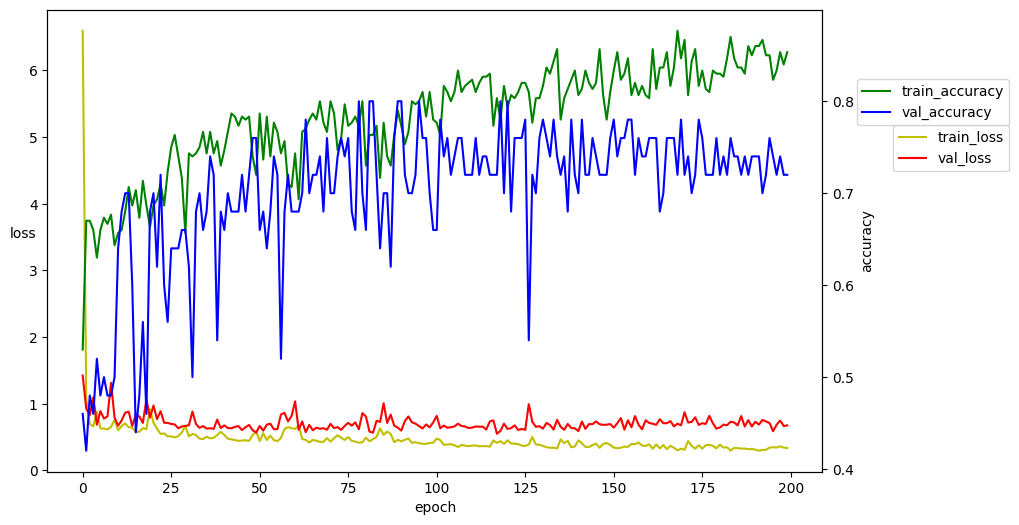

In [206]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.7), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.8), ncol=1)
plt.show()

In [215]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f'정확도 : {accuracy*100:.2f}%')
print()

2/2 [==============================] - 0s 0s/step - loss: 0.4183 - accuracy: 0.8409
정확도 : 84.09%



In [218]:
model.predict(X_test).argmax(axis=1)

2/2 [==============================] - 0s 0s/step


array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0],
      dtype=int64)

In [226]:
y_hat = model.predict(X_test).argmax(axis=1)
ctab = pd.crosstab(y_test.reshape(-1), y_hat.reshape(-1), rownames=['실제값'], colnames=['예측값'])
ctab

2/2 [==============================] - 0s 0s/step


예측값,0,1
실제값,,
0.0,26,4
1.0,3,11


In [227]:
confusion_matrix(y_test, y_hat)

array([[26,  4],
       [ 3, 11]], dtype=int64)

In [225]:
accuracy = (26+11) / (26+4+3+11)
precision = 11 / (11+4)
recall = 11 / (3+11)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1_score:.4f} ({f1_score*100:.2f}%)")

Accuracy : 0.8409 (84.09%)
Precision: 0.7333 (73.33%)
Recall   : 0.7857 (78.57%)
F1-Score : 0.7586 (75.86%)


## 6. 모델 사용하기

In [230]:
print(X_test[0])

[  3.   123.   100.    35.   240.    57.3    0.88  22.  ]


In [232]:
model.predict([[3, 123, 100, 35, 240, 57.3, 0.88, 22]]).argmax()

1/1 [==============================] - 0s 61ms/step


0

In [233]:
print(X_test[10])

[  3.    169.     74.     19.    125.     29.9     0.268  31.   ]


In [234]:
model.predict([[3, 169, 74, 19, 125, 29.9, 0.268, 31]]).argmax()

1/1 [==============================] - 0s 48ms/step


1